In [55]:
import pandas as pd

In [56]:
import matplotlib.pyplot as plt

In [57]:
import seaborn as sns

In [58]:
df = pd.read_csv('/content/online_retail_II.csv', encoding='latin-1')

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
print(df.shape)

(1067371, 8)


In [61]:
print(df.dtypes)

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [62]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [63]:
df = df[~df['Invoice'].astype(str).str.startswith('c')]

In [64]:
df = df.dropna(subset=['Customer ID'])

In [65]:
df = df[(df['Quantity']>0) & (df['Price']>0)]

In [66]:
df['Revenue']=df['Quantity']*df['Price']

In [67]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [68]:
df['Month']=df['InvoiceDate'].dt.to_period('M')

In [69]:
total_customers = df['Customer ID'].nunique()


In [70]:
multi_product = df.groupby('Customer ID')['StockCode'].nunique()
browsed = (multi_product>1).sum()

In [71]:
invoice_counts = df.groupby('Customer ID')['Invoice'].nunique()
repeat = (invoice_counts>1).sum()

In [72]:
funnel = {
    'Total Customers':total_customers,
    'Browsed Products':browsed,
    'Repeat Purchases':repeat
}

In [73]:
stages=list(funnel.keys())
values=list(funnel.values())

In [74]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

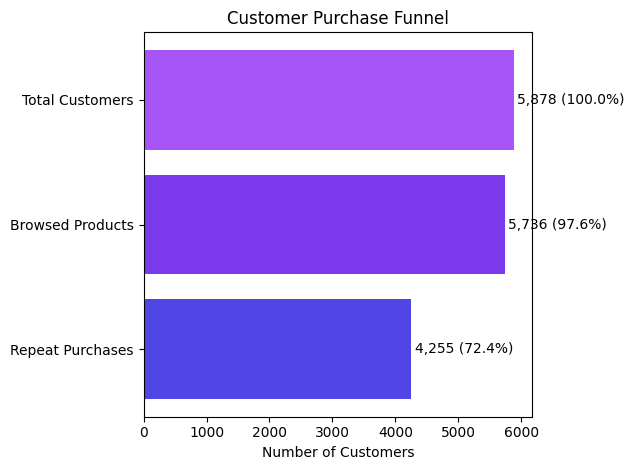

In [75]:
bars = plt.barh(stages[::-1], values[::-1], color=['#4F46E5','#7C3AED','#A855F7','#D946EF'])
plt.xlabel('Number of Customers')
plt.title('Customer Purchase Funnel')
for bar, val in zip(bars, values[::-1]):
  plt.text(bar.get_width() + 50, bar.get_y() +
bar.get_height()/2,
  f'{val:,} ({val/total_customers*100:.1f}%)',
va='center', fontsize=10)
plt.tight_layout()
plt.savefig('funnel.png', dpi=150)

In [76]:
df['CohortMonth']=df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

In [77]:
df['CohortMonth']=(df['Month']-df['CohortMonth']).apply(lambda x: x.n)

In [78]:
cohort_data=df.groupby(['CohortMonth','Month'])['Customer ID'].nunique().reset_index()

In [79]:
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='Month', values='Customer ID')


In [80]:
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)*100

<Axes: xlabel='Month', ylabel='CohortMonth'>

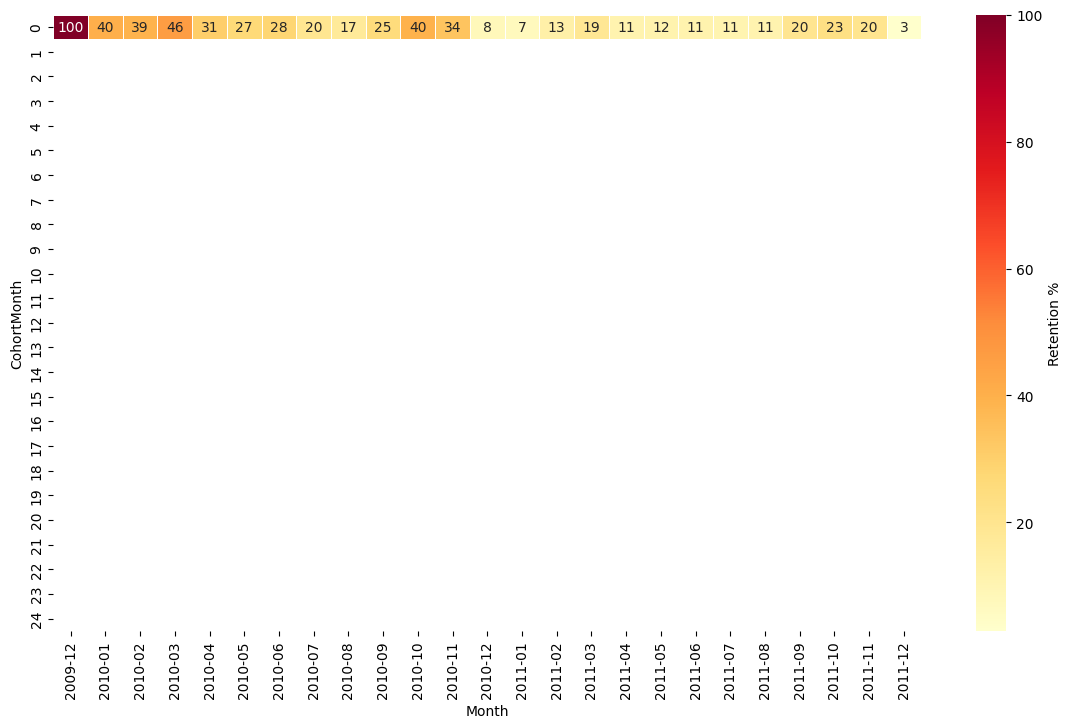

In [81]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Retention %'})

In [82]:
from datetime import datetime

In [83]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

In [84]:
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [85]:
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

In [86]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [87]:
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4,3,2,1])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [88]:
def segment(row):
    r, f = int(row['R_Score']), int(row['F_Score'])
    if r >= 3 and f >= 3:
        return 'Champions'
    elif r >= 3 and f < 3:
        return 'Promising'
    elif r < 3 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost'

In [89]:
rfm['Segment'] = rfm.apply(segment, axis=1)

In [90]:
seg_counts = rfm['Segment'].value_counts()

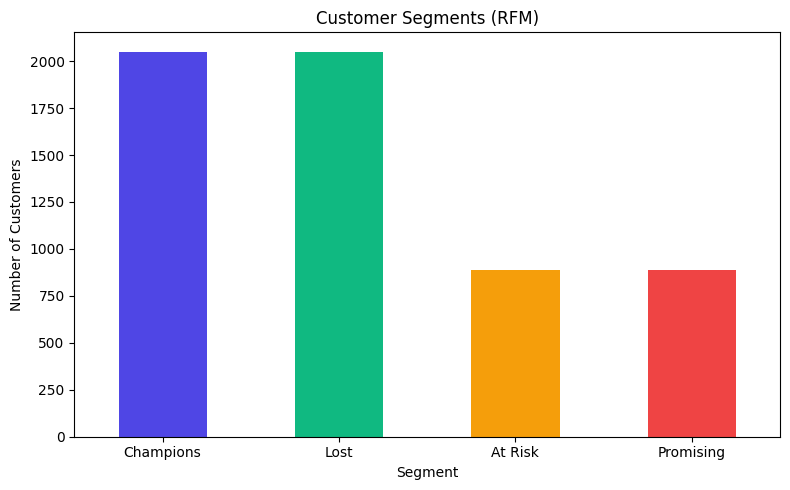

In [91]:
plt.figure(figsize=(8,5))
seg_counts.plot(kind='bar', color=['#4F46E5','#10B981','#F59E0B','#EF4444'])
plt.title('Customer Segments (RFM)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)

In [91]:
--